# Notebook support pour un projet ML supervisé (classification)
## Notebook 1 - Contexte général, analyse exploratoire des données

### Contexte général

<u>Contexte et objectif :</u>  
ESN TechNova Partners, spécialisée dans le conseil en transformation digitale et la vente d'applications SaaS, fait face à un turnover plus élevé que d'habitude.  
Nous sommes mandatés pour identifier les causes et racines potentielles derrière ces démissions.   

**Données d'entrée brutes reçues :** voir le dossier `data\raw`, et notamment les fichiers suivants :   
- `extrait_eval.csv` : un extrait d’un autre SI utilisé pour les évaluations annuelles de performance. On y retrouve des informations telles que les notes de ces évaluations et des notes de satisfaction données par les employés.   
- `extrait_sirh.csv` : un extrait de notre système SIRH où l’on trouve des informations sur la fonction qu’occupe un employé chez nous, ainsi que son âge, son salaire, son ancienneté, etc., ainsi que des informations sociodémographiques.  
- `extrait_sondage.csv` : un sondage à visée bien-être des employés, avec un témoin pour indiquer si l’employé a quitté l’entreprise ou non.   

**Objectif à atteindre :**  
- scorer la probabilité de démission de chaque employé ;
- interpréter le modèle prédictif (SHAP).


<u>**La démarche pour y parvenir suivra les étapes suivantes :**</u>

0. Configurer notre environnement de travail  

    *Création de l’environnement virtuel*  
    *Dans le dossier racine du projet, exécutez : `uv venv`*  
    *Installation des dépendances*   
    *Toujours dans le dossier racine du projet, exécutez : `uv sync`. Pour plus d'informations sur les dépendances, voir `pyproject.toml` (résumé) ou `uv.lock` (détaillé).*  

1. Réaliser une analyse exploratoire des données
2. Préparer les données pour la modélisation
3. Réaliser un premier modèle de classification
4. Améliorer l'approche de classification
5. Optimiser et interpréter le comportement du modèle retenu
6. Formaliser nos résultats


In [23]:
from pathlib import Path
import sys
import importlib

# Détecte automatiquement la racine projet (celle qui contient /src)
project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.Fonctions_EDA as Fonctions_EDA
importlib.reload(Fonctions_EDA)
from src.Fonctions_EDA import eda_overview

# Analyse exploratoire des données
## Jointure des données

<u>Commençons par importer les données contenues dans les trois fichiers sources fournis afin de :</u>  
- rassembler les données par jointure dans un seul dataframe ;  
- faire une lecture globale des données disponibles (numériques, catégorielles, binaires) ;
- choisir les données retenues et la target pour la suite ;
- nettoyer les données retenues ;
- préparer et exporter le jeu de données (état prêt à être modélisé, hors encodage des features catégorielles).


In [24]:
import pandas as pd
from pathlib import Path
import importlib
import math
import matplotlib.pyplot as plt
import seaborn as sns

 
base_path = Path("../data/raw")

df_sondage = pd.read_csv(base_path / "extrait_sondage.csv")
df_sirh = pd.read_csv(base_path / "extrait_sirh.csv")
df_eval = pd.read_csv(base_path / "extrait_eval.csv")

print(df_sondage.shape)
print(df_sirh.shape)
print(df_eval.shape)

(1470, 12)
(1470, 12)
(1470, 10)


Point positif : on observe que les trois fichiers à fusionner ont le même nombre de lignes.

Passons à l'analyse des colonnes pour trouver les colonnes candidates à la jointure :


In [25]:
df_sondage.nunique().sort_values(ascending=False)

code_sondage                           1470
distance_domicile_travail                29
annes_sous_responsable_actuel            18
annees_depuis_la_derniere_promotion      16
nb_formations_suivies                     7
domaine_etude                             6
niveau_education                          5
nombre_participation_pee                  4
frequence_deplacement                     3
a_quitte_l_entreprise                     2
nombre_employee_sous_responsabilite       1
ayant_enfants                             1
dtype: int64

In [26]:
df_sirh.nunique().sort_values(ascending=False)

id_employee                       1470
revenu_mensuel                    1349
age                                 43
annee_experience_totale             40
annees_dans_l_entreprise            37
annees_dans_le_poste_actuel         19
nombre_experiences_precedentes      10
poste                                9
statut_marital                       3
departement                          3
genre                                2
nombre_heures_travailless            1
dtype: int64

In [27]:
df_eval.nunique().sort_values(ascending=False)

eval_number                                  1470
augementation_salaire_precedente               15
niveau_hierarchique_poste                       5
satisfaction_employee_environnement             4
note_evaluation_precedente                      4
satisfaction_employee_nature_travail            4
satisfaction_employee_equilibre_pro_perso       4
satisfaction_employee_equipe                    4
note_evaluation_actuelle                        2
heure_supplementaires                           2
dtype: int64

Premier constat : il n'y a aucune feature nommée de façon identique qui permette de fusionner les sources de données.  
En revanche, on observe 3 features qui peuvent s'apparenter à des identifiants uniques (1 470 entrées différentes pour 1 470 individus).
- Données sondage : feature `code_sondage`
- Données SIRH : feature `id_employee`
- Données évaluation : feature `eval_number`

Nous allons investiguer la construction de ces identifiants pour trouver une clé commune qui permette de fusionner les fichiers entre eux.


In [28]:
df_sondage["code_sondage"].head(20)

0      1
1      2
2      4
3      5
4      7
5      8
6     10
7     11
8     12
9     13
10    14
11    15
12    16
13    18
14    19
15    20
16    21
17    22
18    23
19    24
Name: code_sondage, dtype: int64

In [29]:
df_sirh["id_employee"].head(20)

0      1
1      2
2      4
3      5
4      7
5      8
6     10
7     11
8     12
9     13
10    14
11    15
12    16
13    18
14    19
15    20
16    21
17    22
18    23
19    24
Name: id_employee, dtype: int64

In [30]:
df_eval["eval_number"].head(20)

0      E_1
1      E_2
2      E_4
3      E_5
4      E_7
5      E_8
6     E_10
7     E_11
8     E_12
9     E_13
10    E_14
11    E_15
12    E_16
13    E_18
14    E_19
15    E_20
16    E_21
17    E_22
18    E_23
19    E_24
Name: eval_number, dtype: str

Les deux premiers dataframes (`df_sondage` et `df_sirh`) ont des clés de jointure qui correspondent sans traitement.  
Pour `df_eval`, nous devons retraiter les données contenues dans `eval_number` pour réaliser la jointure.


In [31]:
df_eval["eval_number_jointure"] = (df_eval["eval_number"].str.replace("E_", "", regex=False).astype(int))

df_eval["eval_number_jointure"].head(20)

0      1
1      2
2      4
3      5
4      7
5      8
6     10
7     11
8     12
9     13
10    14
11    15
12    16
13    18
14    19
15    20
16    21
17    22
18    23
19    24
Name: eval_number_jointure, dtype: int64

Les clés de jointure sont toutes de type `int64` et toutes uniques : 1 470 entrées pour 1 470 individus.  
Nous allons maintenant vérifier si elles sont identiques.


In [32]:
cles_eval = df_eval["eval_number_jointure"]
cles_sirh = df_sirh["id_employee"]
cles_sondage = df_sondage["code_sondage"]

set(cles_eval) == set(cles_sirh)

True

In [33]:
set(cles_eval) == set(cles_sondage)

True

In [34]:
set(cles_sirh) == set(cles_sondage)

True

Passons maintenant à la jointure des trois dataframes.


In [35]:
# 1. Harmoniser les clés de jointure
df_eval["id_employee"] = df_eval["eval_number_jointure"].astype(int)
df_sondage["id_employee"] = df_sondage["code_sondage"].astype(int)
df_sirh["id_employee"] = df_sirh["id_employee"].astype(int)

# 2. Jointure des 3 DataFrames
df_global = (df_sirh.merge(df_eval, on="id_employee", how="inner").merge(df_sondage, on="id_employee", how="inner"))

# 3. Suppression des colonnes devenues inutiles
df_global = df_global.drop(columns=["eval_number","eval_number_jointure","code_sondage"], errors="ignore")

# 4. Vérification des dimensions de df_global, on s'attend à 12 + 12 + 10 - 2 = 32 colonnes et 1470 lignes
print(df_global.shape)
df_global.head()

(1470, 32)


,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,...,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,...,0,0,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,...,1,3,1,8,1,Infra & Cloud,Y,Frequent,1,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,...,0,3,1,2,2,Autre,Y,Occasionnel,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,...,0,3,1,3,4,Infra & Cloud,Y,Frequent,3,0
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,...,1,3,1,2,1,Transformation Digitale,Y,Occasionnel,2,2


Passons maintenant à l'exploration de `df_global`.

## Lecture globale des données


In [36]:
eda_overview(df_global)

## 1) Vue globale

,n_lignes,n_colonnes,doublons,%_doublons
0,1470,32,0,0.0


## 2) Qualité des colonnes et cardinalité

,dtype,%null,non_null,null,n_uniques
id_employee,int64,0.0,1470,0,1470
age,int64,0.0,1470,0,43
revenu_mensuel,int64,0.0,1470,0,1349
nombre_experiences_precedentes,int64,0.0,1470,0,10
nombre_heures_travailless,int64,0.0,1470,0,1
annee_experience_totale,int64,0.0,1470,0,40
annees_dans_l_entreprise,int64,0.0,1470,0,37
annees_dans_le_poste_actuel,int64,0.0,1470,0,19
satisfaction_employee_environnement,int64,0.0,1470,0,4
note_evaluation_precedente,int64,0.0,1470,0,4


## 3) Variables numériques (22)

...

,%outliers (IQR),nb_outliers_bas,nb_outliers_haut,min,Q1,median,Q3,max,skew,kurtosis
nb_formations_suivies,16.19,54,184,0,2.00,3.0,3.00,6,0.553124,0.494993
note_evaluation_actuelle,15.37,0,226,3,3.00,3.0,3.00,4,1.921883,1.695939
revenu_mensuel,7.76,0,114,1009,2911.00,4919.0,8379.00,19999,1.369817,1.005233
annees_depuis_la_derniere_promotion,7.28,0,107,0,0.00,1.0,3.00,15,1.984290,3.612673
annees_dans_l_entreprise,7.07,0,104,0,3.00,5.0,9.00,40,1.764529,3.935509
nombre_participation_pee,5.78,0,85,0,0.00,1.0,1.00,3,0.968980,0.364634
annee_experience_totale,4.29,0,63,0,6.00,10.0,15.00,40,1.117172,0.918270
nombre_experiences_precedentes,3.54,0,52,0,1.00,2.0,4.00,9,1.026471,0.010214
annees_dans_le_poste_actuel,1.43,0,21,0,2.00,3.0,7.00,18,0.917363,0.477421
annes_sous_responsable_actuel,0.95,0,14,0,2.00,3.0,7.00,17,0.833451,0.171058


## 4) Variables catégorielles (10)

,n_uniques,null,%null,modalite_top,nb_modalite_top
augementation_salaire_precedente,15,0,0.0,11 %,210
poste,9,0,0.0,Cadre Commercial,326
domaine_etude,6,0,0.0,Infra & Cloud,606
statut_marital,3,0,0.0,Marié(e),673
departement,3,0,0.0,Consulting,961
frequence_deplacement,3,0,0.0,Occasionnel,1043
genre,2,0,0.0,M,882
heure_supplementaires,2,0,0.0,Non,1054
a_quitte_l_entreprise,2,0,0.0,Non,1233
ayant_enfants,1,0,0.0,Y,1470


## 5) Variables temporelles (0)

_Aucune variable datetime._

## Interprétation des résultats

### 1) Global
1 470 lignes x 32 colonnes, sans doublon de colonnes. 

### 2) Qualité des colonnes et cardinalité

| Axe d’analyse | Constat | Implication |
|---|---|---|
| Complétude globale | 0 % de valeurs manquantes sur l’ensemble des 32 variables | Dataset propre, pas de traitement des `NaN` à prévoir à ce stade |
| Clé technique | `id_employee` a 1 470 valeurs uniques pour 1 470 lignes | Identifiant unique, à exclure des variables explicatives |
| Variables numériques à forte cardinalité | `revenu_mensuel` (1 349), `age` (43), `annee_experience_totale` (40), `annees_dans_l_entreprise` (37) | Variables riches en information |
| Variables numériques à faible cardinalité | Scores de satisfaction (4), `niveau_hierarchique_poste` (5), `niveau_education` (5), `note_evaluation_actuelle` (2) | Variables discrètes |
| Variables catégorielles à faible cardinalité | `genre` (2), `heure_supplementaires` (2), `a_quitte_l_entreprise` (2), `statut_marital` (3), `departement` (3), `frequence_deplacement` (3) | Faciles à analyser et à encoder |
| Variables constantes | `nombre_heures_travailless` (1), `nombre_employee_sous_responsabilite` (1), `ayant_enfants` (1) | Variables non informatives, à supprimer |

### 3) Variables numériques (22)

#### 3.1) Complétude des variables numériques

| Axe d’analyse | Variables concernées | Constat | Interprétation |
|---|---|---|---|
| Valeurs manquantes | Toutes | 0 % de `NaN` | Pas de traitement de données manquantes |
| Forte proportion de zéros | `nombre_participation_pee` | 42,93 % | Reflète une non-participation au PEE |
| Forte proportion de zéros | `annees_depuis_la_derniere_promotion` | 39,52 % | Reflète une absence de promotion récente |
| Proportion notable de zéros | `annes_sous_responsable_actuel` | 17,89 % | Reflète une prise de poste récente ou un changement de responsable récent |
| Proportion notable de zéros | `annees_dans_le_poste_actuel` | 16,60 % | Reflète une prise de poste récente (< 1 an) |
| Proportion notable de zéros | `nombre_experiences_precedentes` | 13,40 % | Proportion de profils juniors sans expérience professionnelle précédente |
| Variables sans alerte | Reste des variables | 0 % ou très peu de zéros | Exploitables en l’état |

#### 3.2) Distribution générale des variables numériques

| Axe d’analyse | Variables concernées | Constat | Implication |
|---|---|---|---|
| Outliers élevés | `nb_formations_suivies` | 16,19 % | Distribution atypique à surveiller |
| Outliers élevés | `note_evaluation_actuelle` | 15,37 % | Très faible dispersion, variable à examiner |
| Outliers notables | `revenu_mensuel` | 7,76 % | Forte dispersion, valeurs hautes marquées |
| Outliers notables | `annees_depuis_la_derniere_promotion` | 7,28 % | Distribution asymétrique |
| Outliers notables | `annees_dans_l_entreprise` | 7,07 % | Présence de profils très anciens |
| Asymétrie positive | `revenu_mensuel`, `annees_depuis_la_derniere_promotion`, `annees_dans_l_entreprise`, `annee_experience_totale`, `nombre_experiences_precedentes`, `niveau_hierarchique_poste` | `skew > 1` | Concentration sur de faibles valeurs avec quelques valeurs élevées |
| Variables ordinales | Scores de satisfaction, `niveau_education`, `niveau_hierarchique_poste` | Dispersion cohérente | Variables adaptées à une lecture ordinale |

### 4) Variables catégorielles (10)

| Axe d’analyse | Constat | Implication |
|---|---|---|
| Complétude | 0 % de valeurs manquantes sur les 10 variables | Sous-ensemble propre |
| Faible cardinalité | `genre`, `heure_supplementaires`, `a_quitte_l_entreprise`, `statut_marital`, `departement`, `frequence_deplacement` | Adaptées à l’analyse descriptive et à un encodage simple |
| Cardinalité modérée | `domaine_etude` (6), `poste` (9) | Variables exploitables, à surveiller pour l’encodage |
| Modalité dominante | `departement` = `Consulting` (961) | Distribution déséquilibrée |
| Modalité dominante | `frequence_deplacement` = `Occasionnel` (1 043) | Distribution déséquilibrée |
| Modalité dominante | `heure_supplementaires` = `Non` (1 054) | Distribution déséquilibrée |
| Cible | `a_quitte_l_entreprise` = `Non` (1 233) | Cible déséquilibrée, à prendre en compte en modélisation |
| Variable numérique | `augementation_salaire_precedente` | Valeurs catégorielles ordonnées en apparence, à transformer en variable numérique |

### 5) Variables temporelles (0)

| Axe d’analyse | Constat | Implication |
|---|---|---|
| Présence de variables datetime | Aucune | Pas d’analyse temporelle possible en l’état |


In [37]:
df_global["augementation_salaire_precedente"].unique()

<StringArray>
['11 %', '23 %', '15 %', '12 %', '13 %', '20 %', '22 %', '21 %', '17 %',
 '14 %', '16 %', '18 %', '19 %', '24 %', '25 %']
Length: 15, dtype: str

In [38]:
df_global["augementation_salaire_precedente"] = (df_global["augementation_salaire_precedente"].str.replace("%", "", regex=False).str.strip().astype(float).div(100))
df_global["augementation_salaire_precedente"].describe()

count    1470.000000
mean        0.152095
std         0.036599
min         0.110000
25%         0.120000
50%         0.140000
75%         0.180000
max         0.250000
Name: augementation_salaire_precedente, dtype: float64

## Choix des features et de la target


Dans cette étude, la distinction entre variables numériques et catégorielles est faite selon leur traitement futur dans le pipeline de préparation des données.  
Les variables conservées dans `num_cols` sont des variables déjà numériques, qui ne nécessitent pas d’encodage, même lorsqu’elles sont discrètes ou ordinales.  
Les variables placées dans `cat_cols` correspondent aux variables qui devront faire l’objet d’un encodage avant modélisation.

In [40]:
target = "a_quitte_l_entreprise"

num_cols = [
    "age",
    "revenu_mensuel",
    "nombre_experiences_precedentes",
    "annee_experience_totale",
    "annees_dans_l_entreprise",
    "annees_dans_le_poste_actuel",
    "satisfaction_employee_environnement",
    #"note_evaluation_precedente",
    "niveau_hierarchique_poste",
    "satisfaction_employee_nature_travail",
    "satisfaction_employee_equipe",
    "satisfaction_employee_equilibre_pro_perso",
    #"note_evaluation_actuelle",
    "nombre_participation_pee",
    "nb_formations_suivies",
    "distance_domicile_travail",
    "niveau_education",
    "annees_depuis_la_derniere_promotion",
    "annes_sous_responsable_actuel",
    "augementation_salaire_precedente"
]

cat_cols = [
    "genre",
    "statut_marital",
    "departement",
    "poste",
    "heure_supplementaires",
    "domaine_etude",
    "frequence_deplacement"
]

drop_cols = [
    "id_employee",
    "nombre_heures_travailless",
    "nombre_employee_sous_responsabilite",
    "ayant_enfants",
]

Maintenant que nous avons choisi nos features et notre target, passons à leur analyse.

## Analyse univariée des features numériques


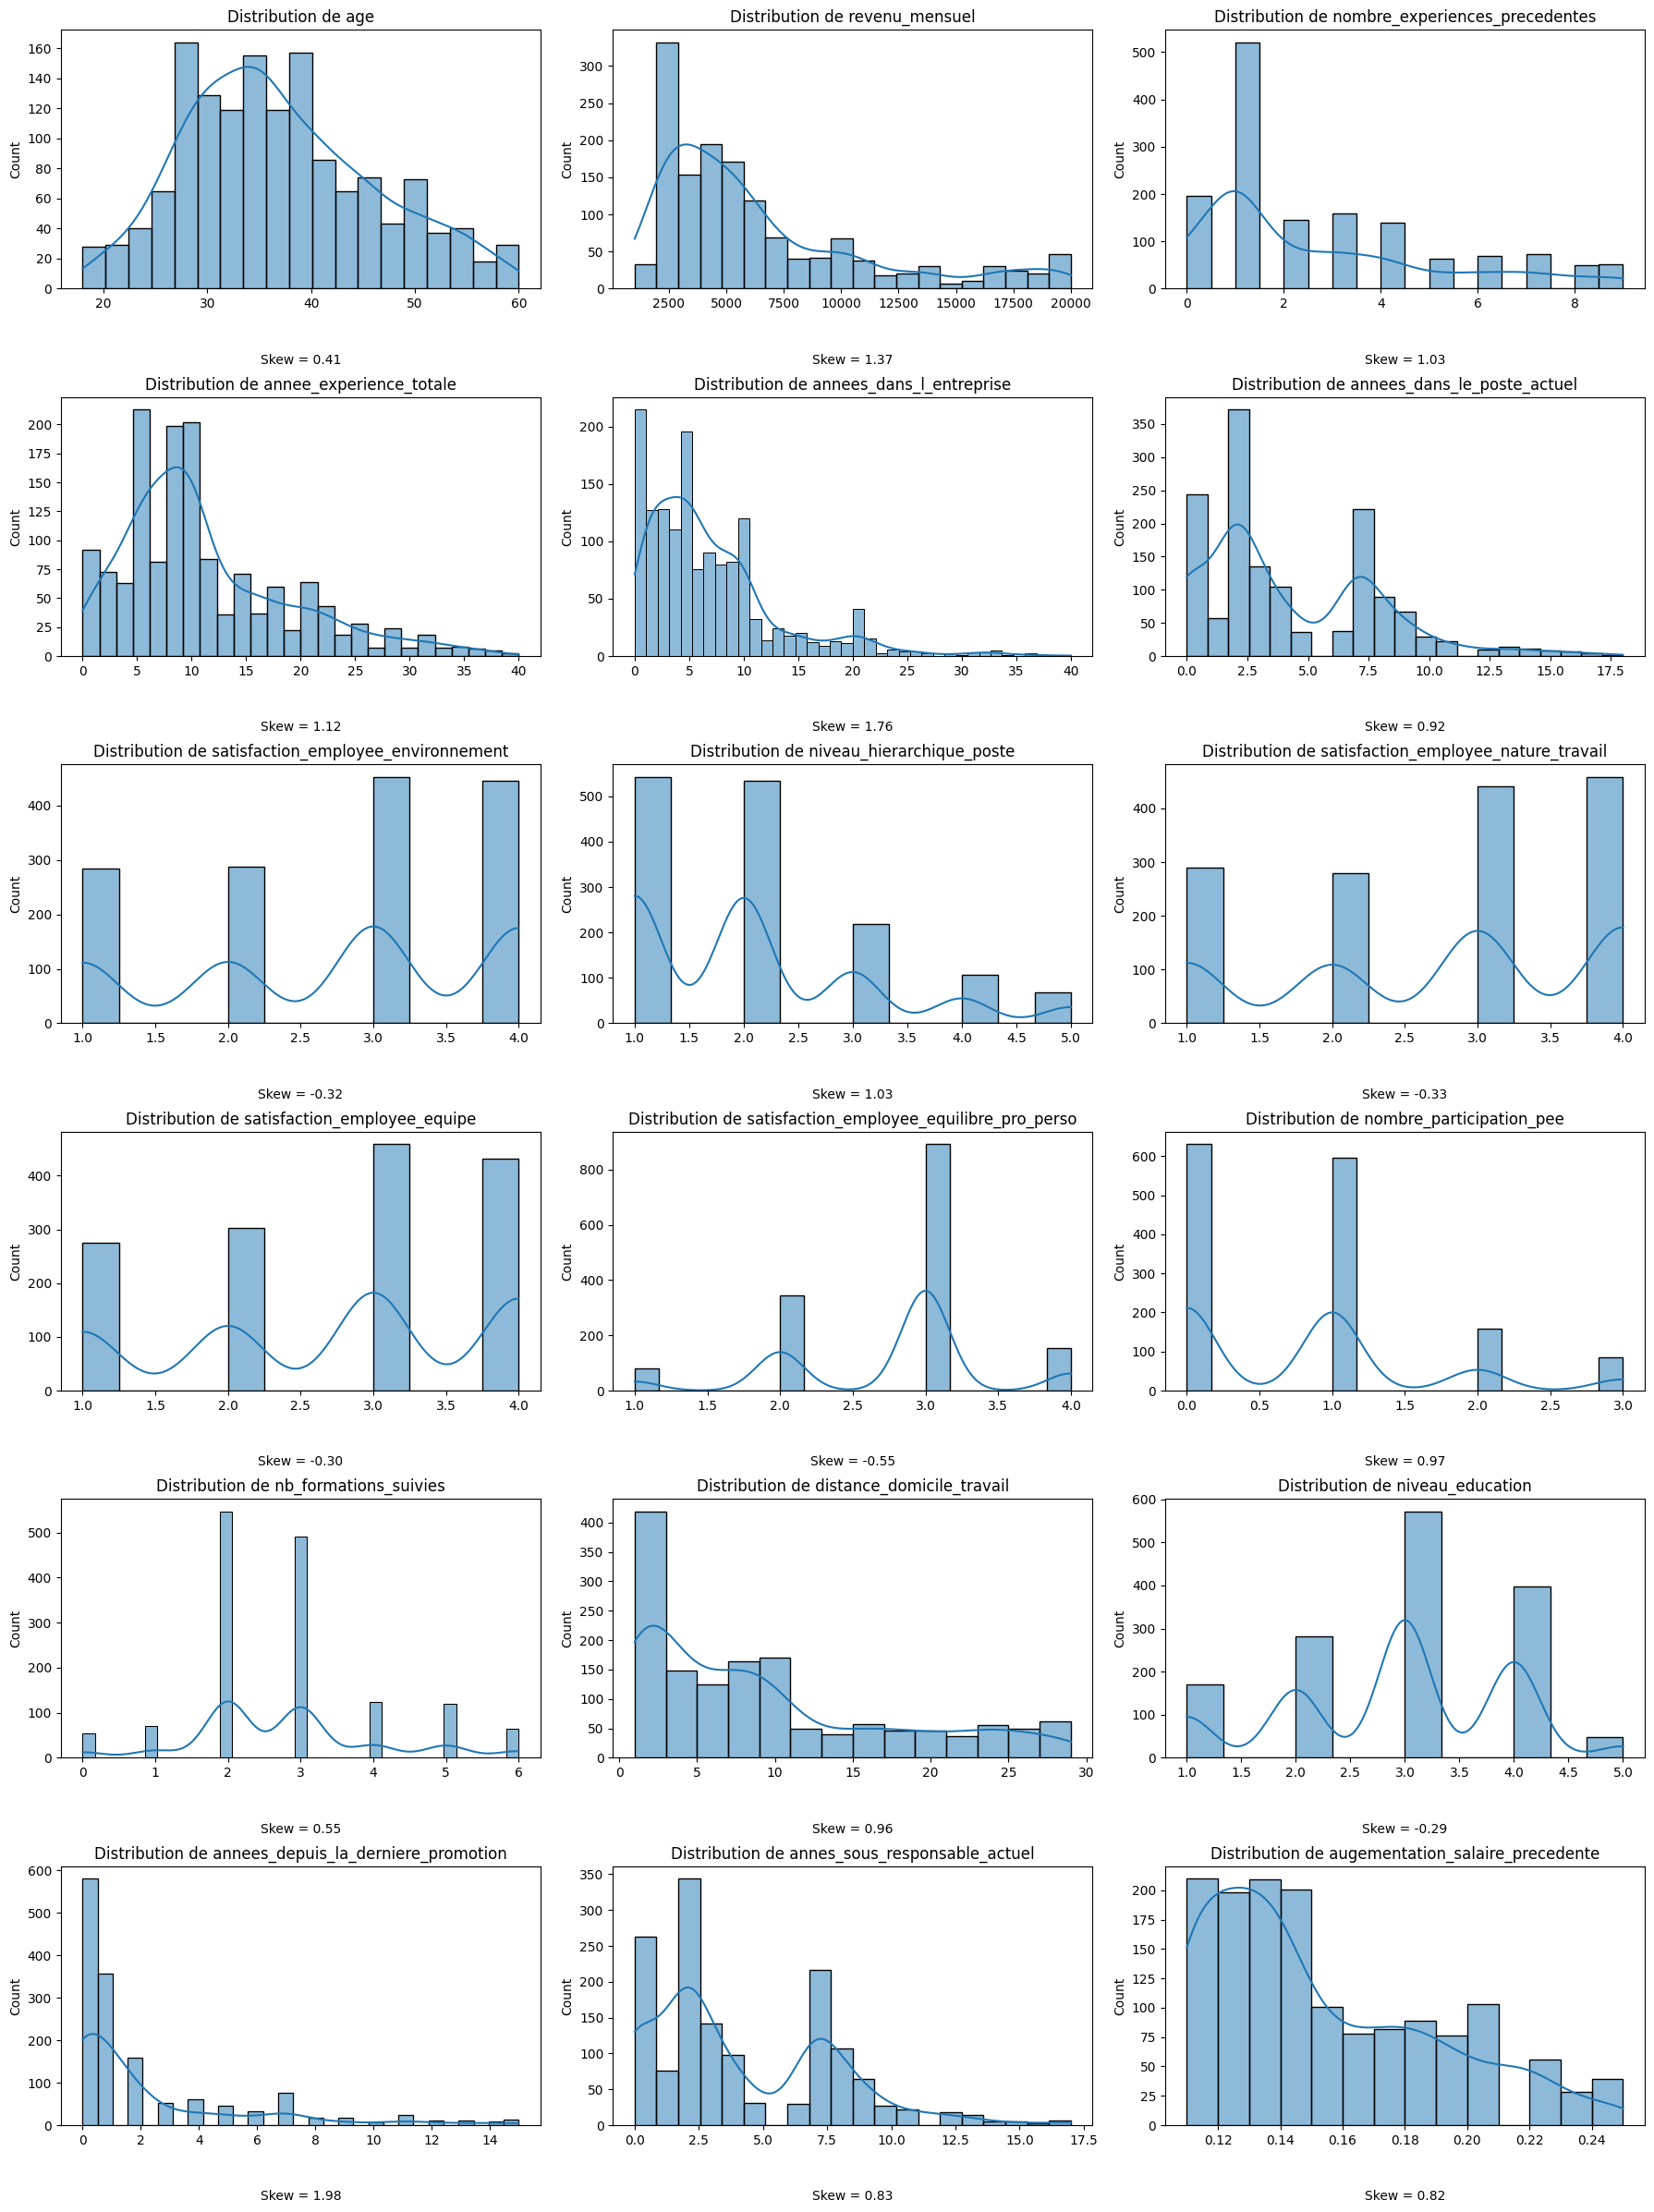

In [41]:
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    skew_value = df_global[col].skew()

    sns.histplot(df_global[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution de {col}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].text(
        0.5, -0.25,
        f"Skew = {skew_value:.2f}",
        transform=axes[i].transAxes,
        ha="center",
        va="top"
    )

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



## Conclusion générale

Les variables numériques ne suivent pas, pour la plupart, une distribution normale.  
On observe beaucoup de distributions asymétriques à droite : la majorité des individus sont concentrés sur des valeurs faibles ou moyennes, avec une minorité de valeurs élevées.  
Plusieurs variables sont discrètes ou ordinales ; les histogrammes doivent donc être interprétés comme des distributions de modalités, et non comme de vraies variables continues.  

### Variables continues / quasi continues

- `age` a une distribution relativement équilibrée, proche d’une forme unimodale, sans anomalie majeure.
- `revenu_mensuel` est fortement asymétrique à droite :
  - beaucoup de salaires dans la partie basse à moyenne ;
  - quelques salaires très élevés ;
  - présence probable d’outliers.
- `annee_experience_totale`, `annees_dans_l_entreprise`, `annees_dans_le_poste_actuel`, `annees_depuis_la_derniere_promotion`, `annes_sous_responsable_actuel` sont aussi asymétriques à droite :
  - beaucoup de profils récents ;
  - peu de profils très anciens ;
  - cela est cohérent d’un point de vue métier, surtout au regard de la problématique de turnover rencontrée par l'entreprise.

### Variables avec beaucoup de zéros

- `nombre_experiences_precedentes`
- `nombre_participation_pee`
- `annees_depuis_la_derniere_promotion`
- `annes_sous_responsable_actuel`

Sur ces variables, nous avons déjà statué sur l'interprétation métier associée. Voir ci-avant.

### Variables ordinales

- `satisfaction_employee_environnement`
- `note_evaluation_precedente`
- `niveau_hierarchique_poste`
- `satisfaction_employee_nature_travail`
- `satisfaction_employee_equipe`
- `satisfaction_employee_equilibre_pro_perso`
- `note_evaluation_actuelle`
- `niveau_education`

Pour celles-ci :

- les valeurs sont regroupées sur peu de modalités, ce qui est normal ;
- elles doivent être lues comme des scores ou des niveaux.

### Implications pour la suite

Pas besoin de supposer la normalité.  
Les transformations peuvent être utiles pour certaines variables très asymétriques, surtout :
- `revenu_mensuel`
- `annee_experience_totale`
- `annees_dans_l_entreprise`

Les variables ordinales doivent être traitées comme des niveaux ordonnés.  
Les variables avec beaucoup de zéros peuvent être conservées telles quelles, car ces zéros semblent porter une information métier.


## Analyse univariée des features catégorielles


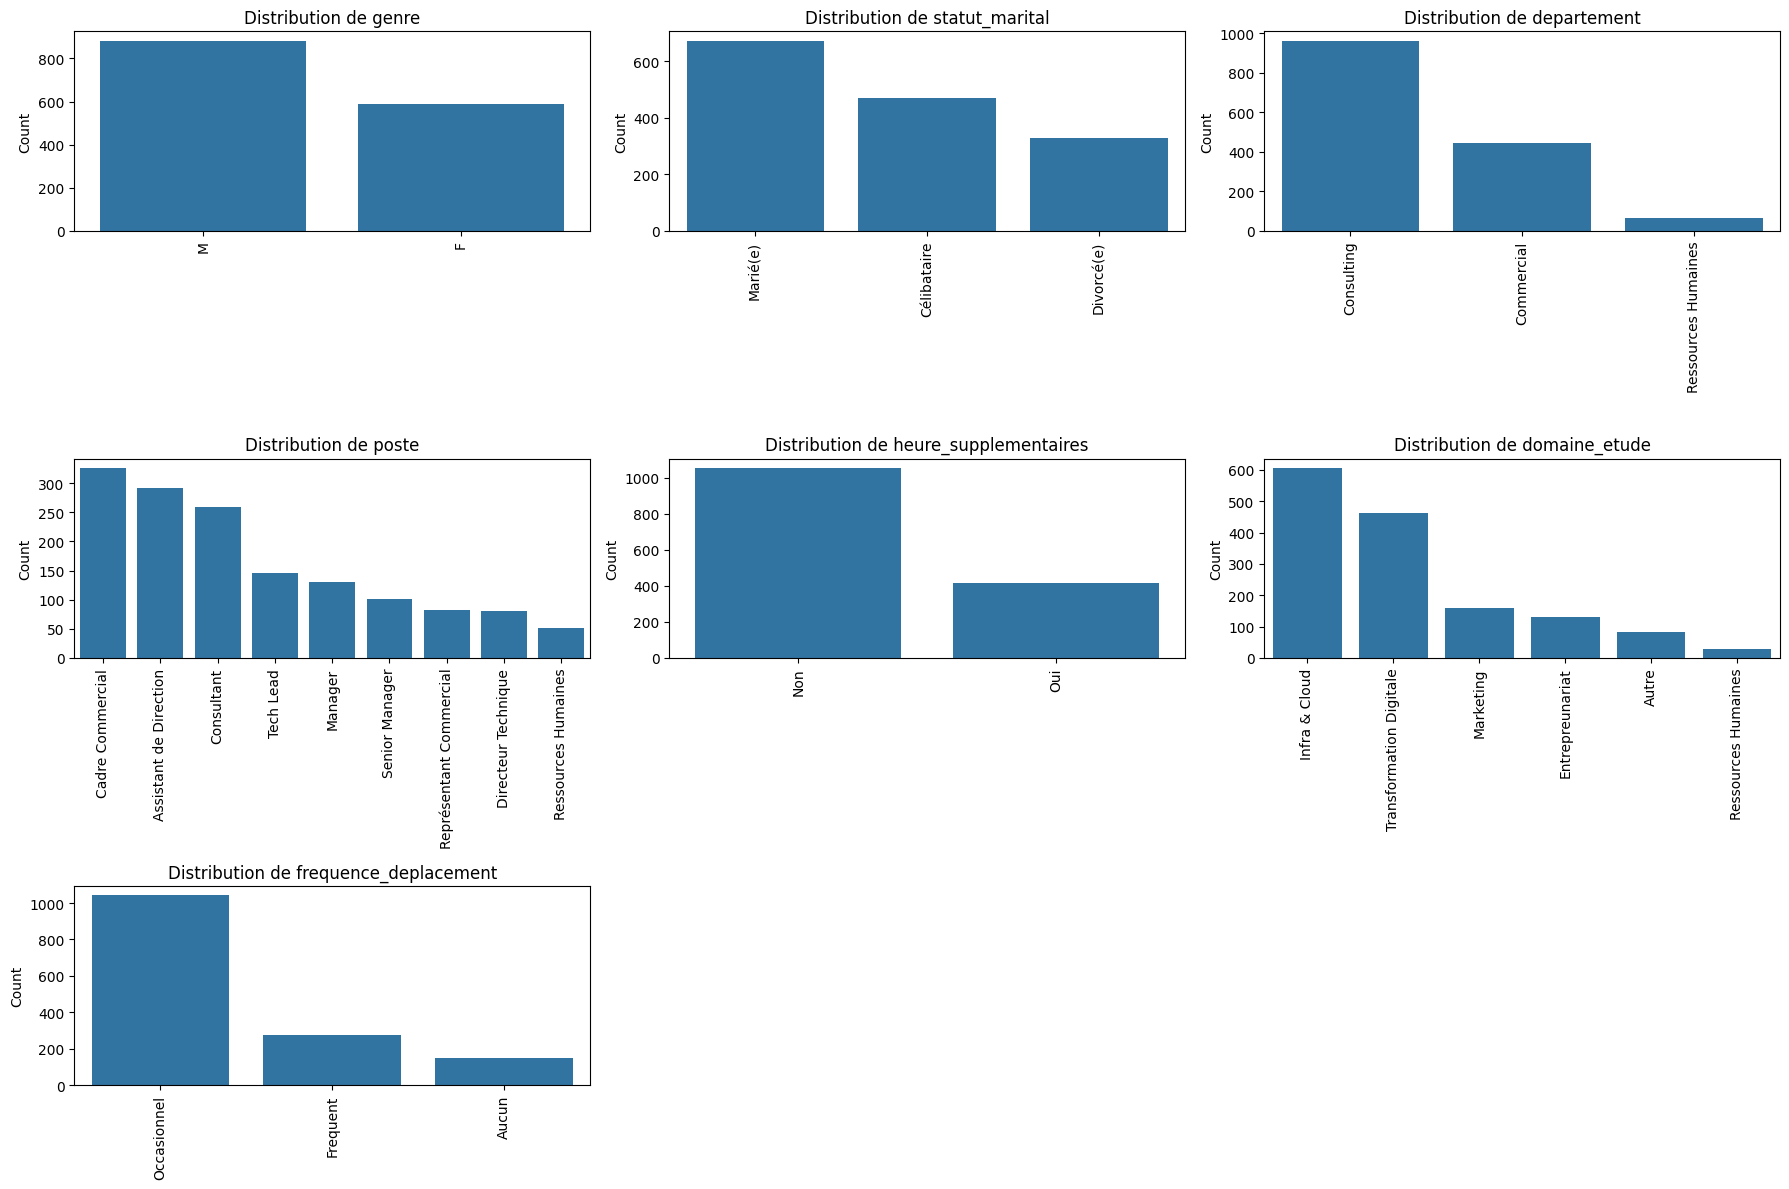

In [42]:
n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df_global[col].value_counts().index
    sns.countplot(data=df_global, x=col, order=order, ax=axes[i])
    axes[i].set_title(f"Distribution de {col}")
    axes[i].tick_params(axis="x", rotation=90)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## Analyse univariée des features catégorielles

L’analyse univariée des variables catégorielles met en évidence des distributions globalement exploitables, avec des cardinalités faibles à modérées.   
Les variables sont faciles à lire et à interpréter, mais plusieurs d’entre elles présentent un déséquilibre marqué entre modalités, ce qui devra être pris en compte dans l’analyse bivariée puis en modélisation.    

La variable `genre` est modérément déséquilibrée, avec une majorité d’hommes.   
`statut_marital` présente également une répartition inégale, la modalité `Marié(e)` étant la plus fréquente, suivie de `Célibataire`, puis `Divorcé(e)`. Ces variables restent néanmoins suffisamment variées pour être informatives.  
La variable `departement` est fortement dominée par `Consulting`, très loin devant `Commercial`, tandis que `Ressources Humaines` est nettement minoritaire.   
On retrouve une logique similaire dans `frequence_deplacement`, où la modalité `Occasionnel` est très largement majoritaire, devant `Fréquent`, puis `Aucun`.   

**Ces déséquilibres traduisent une structure de population non homogène.**  

La variable `poste` présente une cardinalité plus élevée mais reste exploitable.   
La répartition montre une concentration sur quelques fonctions, notamment `Cadre Commercial`, `Assistant de Direction` et `Consultant`, tandis que certains postes sont beaucoup moins représentés.   
**La présence de `Assistant de Direction` parmi les modalités les plus fréquentes apparaît néanmoins assez surprenante et mériterait d’être vérifiée ou contextualisée d’un point de vue métier.**  

Enfin, `domaine_etude` montre aussi une distribution déséquilibrée, avec une nette surreprésentation de `Infra & Cloud`, suivie de `Transformation Digitale`. Les autres domaines sont plus faiblement représentés.  
Cette variable semble informative, mais certaines modalités peu fréquentes pourraient avoir un poids statistique limité.  

### Conclusions
Dans l’ensemble, les variables catégorielles sont exploitables, mais plusieurs présentent une forte concentration sur une ou deux modalités dominantes.   
Il faudra en tenir compte pour interpréter correctement leurs liens avec la variable cible et, si besoin, envisager un regroupement des modalités les plus rares.   

### Listes finales des features / target et colonnes supprimées


In [43]:
target = "a_quitte_l_entreprise"

num_cols = [
    "age",
    "revenu_mensuel",
    "nombre_experiences_precedentes",
    "annee_experience_totale",
    "annees_dans_l_entreprise",
    "annees_dans_le_poste_actuel",
    "satisfaction_employee_environnement",
    "note_evaluation_precedente",
    "niveau_hierarchique_poste",
    "satisfaction_employee_nature_travail",
    "satisfaction_employee_equipe",
    "satisfaction_employee_equilibre_pro_perso",
    "nombre_participation_pee",
    "nb_formations_suivies",
    "distance_domicile_travail",
    "niveau_education",
    "annees_depuis_la_derniere_promotion",
    "annes_sous_responsable_actuel",
    "augementation_salaire_precedente"
]

txt_cols = [
    "genre",
    "statut_marital",
    "departement",
    "poste",
    "heure_supplementaires",
    "domaine_etude",
    "frequence_deplacement"
]

drop_cols = [
    "id_employee",
    "nombre_heures_travailless",
    "nombre_employee_sous_responsabilite",
    "ayant_enfants",
]

## Analyse bivariée des features numériques


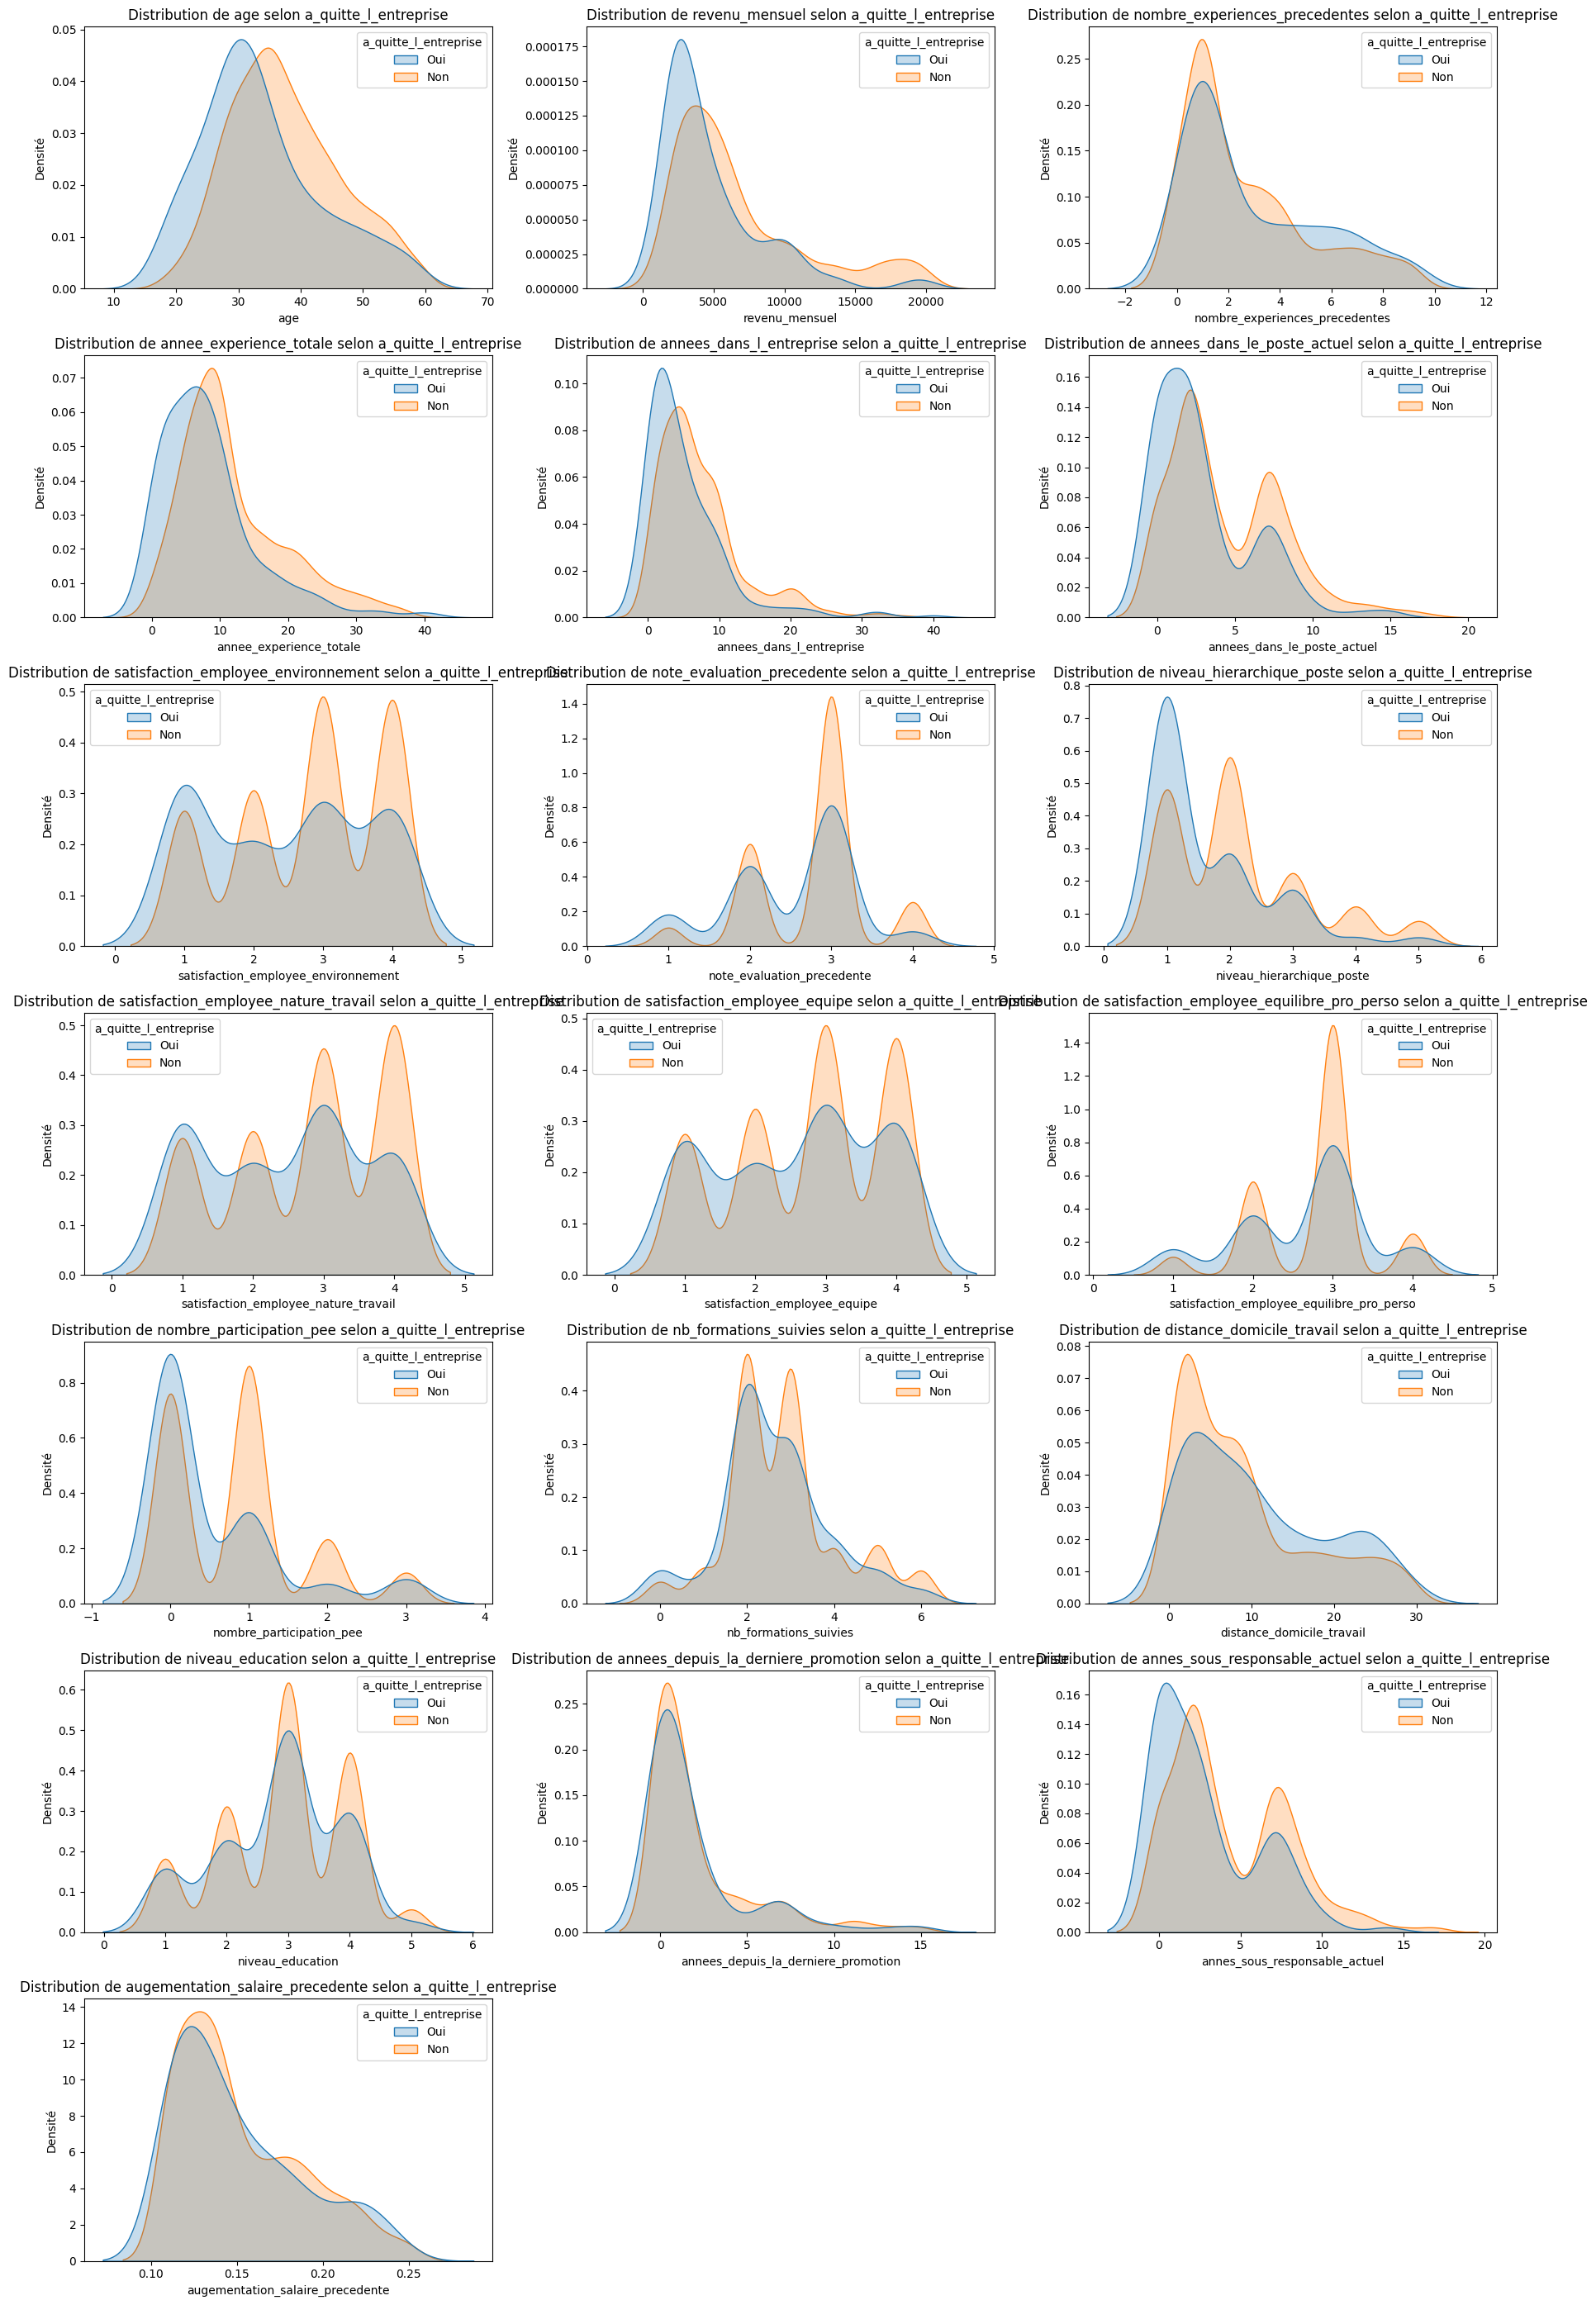

In [44]:
n_cols_plot = 3
n_rows_plot = math.ceil(len(num_cols) / n_cols_plot)

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, 4 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(data=df_global, x=col, hue=target, fill=True, common_norm=False, ax=axes[i])
    axes[i].set_title(f"Distribution de {col} selon {target}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Densité")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

plt.show()


L’analyse bivariée des variables numériques par rapport à la cible montre un recouvrement important entre les distributions des salariés ayant quitté l’entreprise et de ceux qui y sont restés.  
Cela suggère qu’aucune variable numérique, prise isolément, ne permet de discriminer parfaitement la variable cible.  
En revanche, certaines variables présentent des écarts visibles et semblent plus informatives.

Les variables les plus différenciantes visuellement sont `age`, `revenu_mensuel`, `annee_experience_totale`, `annees_dans_l_entreprise`, `annees_dans_le_poste_actuel`, `niveau_hierarchique_poste`, `distance_domicile_travail` et `nombre_participation_pee`.  
Globalement, les départs paraissent plus fréquents chez des profils plus jeunes, moins expérimentés, avec une ancienneté plus faible, un niveau hiérarchique plus bas et des revenus plus modestes.

À l’inverse, plusieurs variables montrent des distributions très proches entre les deux classes, notamment les scores de satisfaction, les notes d’évaluation, le niveau d’éducation ou encore les années depuis la dernière promotion.  
Ces variables ne semblent pas fortement discriminantes prises individuellement, mais peuvent néanmoins contribuer à l’explication du phénomène lorsqu’elles sont combinées avec d’autres variables dans une approche multivariée.


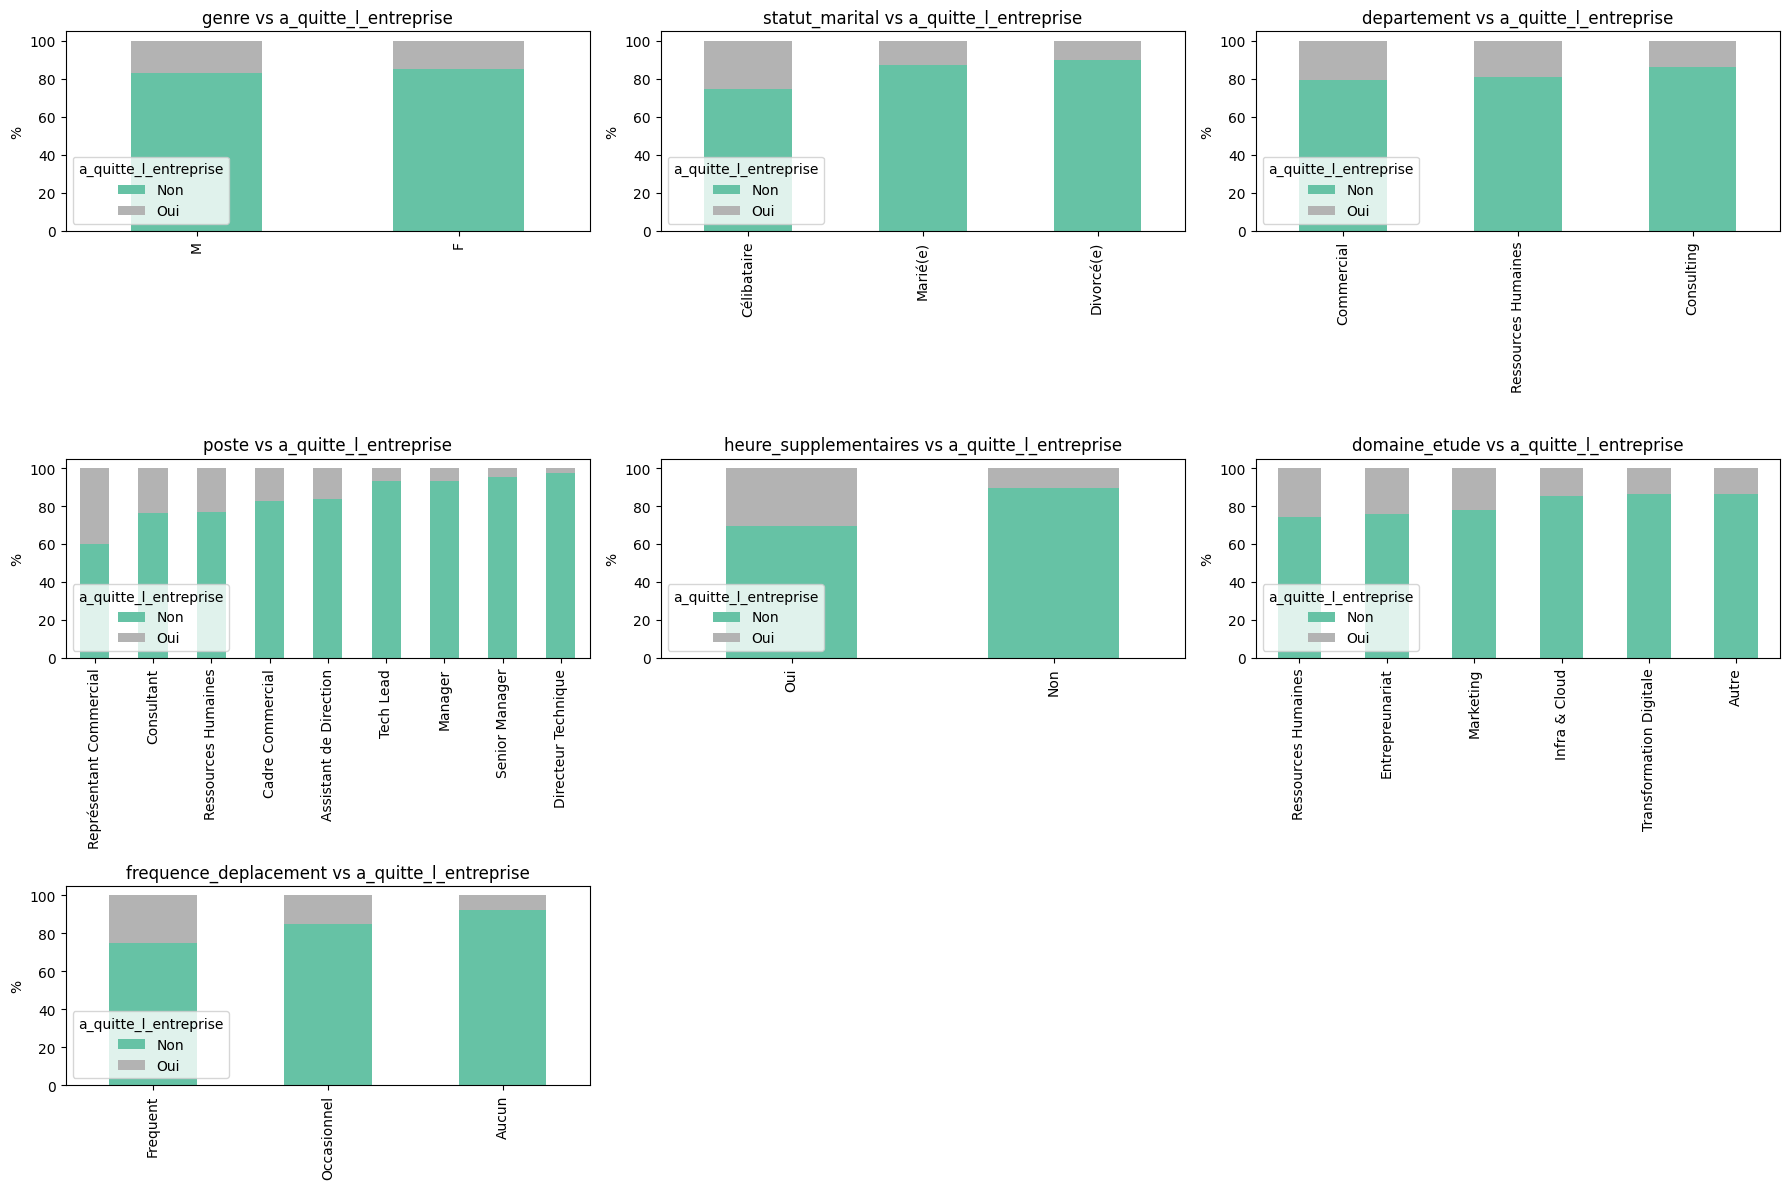

In [45]:
n_cols_plot = 3
n_rows_plot = math.ceil(len(cat_cols) / n_cols_plot)

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, 4 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    prop_df = pd.crosstab(df_global[col], df_global[target], normalize="index") * 100
    prop_df = prop_df.sort_values(by="Oui", ascending=False)
    
    prop_df.plot(
        kind="bar",
        stacked=True,
        ax=axes[i],
        colormap="Set2"
    )
    
    axes[i].set_title(f"{col} vs {target}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("%")
    axes[i].tick_params(axis="x", rotation=90)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## Analyse des features catégorielles avec la cible

L’analyse bivariée des variables catégorielles par rapport à `a_quitte_l_entreprise` met en évidence plusieurs écarts de proportions entre modalités.  
Ces écarts ne sont pas uniformes selon les variables, mais certaines catégories semblent clairement plus associées au départ que d’autres.

La variable `genre` montre un écart modéré entre les modalités : la proportion de départ semble légèrement plus élevée chez les femmes que chez les hommes.  
L’effet reste visible mais relativement limité.

`statut_marital` apparaît plus discriminante.  
Les salariés `Célibataire` semblent présenter une proportion de départ plus élevée que les `Marié(e)` et les `Divorcé(e)`.  
À l’inverse, les salariés mariés ou divorcés paraissent plus stables.

La variable `departement` met en évidence des différences intéressantes.  
Les départs semblent proportionnellement plus fréquents dans les départements `Commercial` et `Ressources Humaines` que dans `Consulting`, qui apparaît comme le département le plus stable.  
Cela suggère un effet possible du contexte métier ou organisationnel selon le service.

La variable `poste` semble également informative, avec des écarts de taux de départ entre fonctions.  
Certaines catégories comme `Représentant Commercial`, `Consultant` ou `Ressources Humaines` paraissent davantage associées au départ, tandis que des postes comme `Manager`, `Senior Manager` ou `Directeur Technique` semblent plus stables.  
Cette lecture doit toutefois rester prudente pour les modalités les moins fréquentes, car de petits effectifs peuvent amplifier visuellement les écarts.

La variable `heure_supplementaires` ressort comme particulièrement discriminante.  
Les salariés déclarant effectuer des heures supplémentaires (`Oui`) semblent quitter l’entreprise nettement plus souvent que ceux n’en effectuant pas (`Non`).  
C’est l’un des signaux les plus visibles parmi les variables catégorielles.

`domaine_etude` montre aussi des différences de comportement selon les modalités.  
Les domaines `Ressources Humaines`, `Entrepreneuriat` et `Marketing` semblent présenter des proportions de départ plus élevées que `Infra & Cloud`, `Transformation Digitale` ou `Autre`, qui paraissent plus stables.

Enfin, `frequence_deplacement` semble associée à la cible.  
Les salariés se déplaçant `Fréquent` paraissent plus susceptibles de quitter l’entreprise que ceux se déplaçant `Occasionnel`, tandis que la modalité `Aucun` semble la plus stable.  
Cela peut suggérer un effet de la mobilité professionnelle sur le risque de départ.

Dans l’ensemble, plusieurs variables catégorielles montrent un lien visible avec la cible, en particulier `heure_supplementaires`, `frequence_deplacement`, `statut_marital`, `departement` et certains `poste`.  
Ces variables semblent donc pertinentes pour la suite de l’analyse et pour la modélisation.


## Export du DataFrame après EDA

Le dataframe exporté à l’issue de cette phase contient **1 470 lignes et 32 colonnes**.  
Il correspond au jeu nettoyé et consolidé qui servira de point d’entrée pour la phase de feature engineering.


In [46]:
df_global.shape

(1470, 32)

In [47]:
output_path = Path("../data/processed/df_EDA.csv")
df_global.to_csv(output_path, index=False)

## Contrôles explicites de qualité et de périmètre

Cette section formalise explicitement les vérifications de suppression potentielle de lignes :
- doublons techniques ;
- incohérences métier manifestes ;
- observations hors périmètre ;
- risque de fuite d'information temporelle.

Les contrôles exécutés ci-dessous confirment finalement l’absence d’alerte : **0 doublon exact, 0 doublon sur `id_employee` et 0 incohérence métier détectée** sur le périmètre conservé.


In [48]:
# 1) Controles explicites des doublons et incoherences metier

row_duplicates = int(df_global.duplicated().sum())
id_duplicates = int(df_global['id_employee'].duplicated().sum())

target_ok = set(df_global['a_quitte_l_entreprise'].dropna().unique()) <= {'Oui', 'Non'}

checks = {
    'age_hors_plage_[16,70]': (df_global['age'] < 16) | (df_global['age'] > 70),
    'anciennete_sup_experience_totale': df_global['annees_dans_l_entreprise'] > df_global['annee_experience_totale'],
    'anciennete_poste_sup_anciennete_entreprise': df_global['annees_dans_le_poste_actuel'] > df_global['annees_dans_l_entreprise'],
    'anciennete_manager_sup_anciennete_entreprise': df_global['annes_sous_responsable_actuel'] > df_global['annees_dans_l_entreprise'],
    'annees_depuis_promo_sup_anciennete_entreprise': df_global['annees_depuis_la_derniere_promotion'] > df_global['annees_dans_l_entreprise'],
    'experience_sup_age_moins_14': df_global['annee_experience_totale'] > (df_global['age'] - 14),
    'revenu_non_positif': df_global['revenu_mensuel'] <= 0,
    'distance_negative': df_global['distance_domicile_travail'] < 0,
}

check_summary = pd.DataFrame({
    'controle': list(checks.keys()),
    'nb_lignes_en_alerte': [int(mask.sum()) for mask in checks.values()],
})
check_summary['pct_lignes_en_alerte'] = (check_summary['nb_lignes_en_alerte'] / len(df_global) * 100).round(2)

print(f'Doublons de lignes exactes: {row_duplicates}')
print(f'Doublons sur id_employee: {id_duplicates}')
print(f'Classes cibles valides Oui/Non: {target_ok}')
display(check_summary.sort_values(by='nb_lignes_en_alerte', ascending=False))

# Lignes concernees par au moins une incoherence metier
any_issue_mask = pd.concat(checks.values(), axis=1).any(axis=1)
print(f'Nombre total de lignes avec au moins une alerte metier: {int(any_issue_mask.sum())}')
display(df_global.loc[any_issue_mask, ['id_employee','age','annee_experience_totale','annees_dans_l_entreprise','annees_dans_le_poste_actuel','annes_sous_responsable_actuel','annees_depuis_la_derniere_promotion','revenu_mensuel','distance_domicile_travail']].head(10))


Doublons de lignes exactes: 0
Doublons sur id_employee: 0
Classes cibles valides Oui/Non: True


,controle,nb_lignes_en_alerte,pct_lignes_en_alerte
0,"age_hors_plage_[16,70]",0,0.0
1,anciennete_sup_experience_totale,0,0.0
2,anciennete_poste_sup_anciennete_entreprise,0,0.0
3,anciennete_manager_sup_anciennete_entreprise,0,0.0
4,annees_depuis_promo_sup_anciennete_entreprise,0,0.0
5,experience_sup_age_moins_14,0,0.0
6,revenu_non_positif,0,0.0
7,distance_negative,0,0.0


Nombre total de lignes avec au moins une alerte metier: 0


,id_employee,age,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,annes_sous_responsable_actuel,annees_depuis_la_derniere_promotion,revenu_mensuel,distance_domicile_travail
